# CoNLL-2003 Data, EDA and Experimental Split Registry

## Purpose

This notebook establishes the dataset partitions used throughout the dissertation and acts as the **single source of truth for the experimental split registry**.

It has four main purposes:

1. load the CoNLL-2003 training and validation data;
2. perform exploratory analysis relevant to named-entity recognition and span-based modelling;
3. create fixed validation and parent-calibration populations from the original CoNLL-2003 validation split;
4. divide the parent-calibration population into separate probability-calibration and conformal-calibration subsets.

The original CoNLL-2003 validation split contains 3,250 sentences. A deterministic 50:50 split with seed 42 is used to create:

- **Validation:** 1,625 sentences, used for model development, validation and model-selection decisions.
- **Parent calibration:** 1,625 sentences, reserved from model-selection decisions.

The parent-calibration population is then divided into:

- **Probability calibration:** 975 sentences, used for probability-calibration procedures.
- **Conformal calibration:** 650 sentences, used only for fitting conformal thresholds.

During the 975/650 subdivision, sentences with identical token sequences are kept within the same calibration subset to avoid exact duplicate text crossing between the two calibration populations.

The official CoNLL-2003 test split is reserved exclusively for the final locked evaluation and is **not loaded or inspected in this notebook**.

All split assignments, identifiers and integrity checks produced here are saved for use by downstream notebooks.

## 1. Setup and reproducibility

Only the packages needed for loading, analysing, plotting, and saving the dataset partitions are imported here.

In [1]:
from pathlib import Path
import hashlib
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from datasets import DatasetDict, load_dataset



# Reproducibility


SEED = 42
SPLIT_SEED = 42
CALIBRATION_SUBSPLIT_SEED = 42


# Dataset configuration

DATASET_NAME = "lhoestq/conll2003"

TARGET_VALIDATION = 1625
TARGET_PARENT_CALIBRATION = 1625

TARGET_PROBABILITY_CALIBRATION = 975
TARGET_CONFORMAL_CALIBRATION = 650


# Output paths

OUTPUT_DIR = Path(
    "/kaggle/working/00_data_eda_split_registry"
)

FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Global reproducibility settings

random.seed(SEED)
np.random.seed(SEED)

pd.set_option(
    "display.max_columns",
    50,
)

pd.set_option(
    "display.width",
    120,
)


print("Global random seed:", SEED)
print("Validation/calibration split seed:", SPLIT_SEED)
print(
    "Calibration subdivision seed:",
    CALIBRATION_SUBSPLIT_SEED,
)
print("Output directory:", OUTPUT_DIR)

Global random seed: 42
Validation/calibration split seed: 42
Calibration subdivision seed: 42
Output directory: /kaggle/working/00_data_eda_split_registry


## 2. Load the CoNLL-2003 Development Data

Only the official CoNLL-2003 **training** and **validation** splits are loaded at this stage.

The training split is used for model fitting in later notebooks, while the original validation split is used here to construct the validation and calibration populations.

The official test split is deliberately left untouched until the final locked evaluation.

In [2]:
train_dataset = load_dataset(
    DATASET_NAME,
    split="train",
)

original_validation_dataset = load_dataset(
    DATASET_NAME,
    split="validation",
)


dataset = DatasetDict({
    "train": train_dataset,
    "validation": original_validation_dataset,
})


print("CoNLL-2003 development data loaded successfully.")
print(f"Training sentences: {len(train_dataset):,}")
print(
    "Original validation sentences:",
    f"{len(original_validation_dataset):,}",
)
print("Official test split loaded: False")

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

CoNLL-2003 development data loaded successfully.
Training sentences: 14,041
Original validation sentences: 3,250
Official test split loaded: False


## 3. Inspect the Dataset Structure

CoNLL-2003 represents each sentence as a sequence of tokens with corresponding token-level annotations.

The fields relevant to this dissertation are:

- `tokens`: the words in the sentence;
- `ner_tags`: integer IDs representing BIO named-entity labels.

Part-of-speech and chunk annotations are also included in the dataset, but they are not used in the experiments.

In [3]:
example = train_dataset[0]

print("Available fields:")
print(list(example.keys()))

print("\nTokens:")
print(example["tokens"])

print("\nNER tag IDs:")
print(example["ner_tags"])

print("\nDataset feature schema:")
print(train_dataset.features)

Available fields:
['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags']

Tokens:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

NER tag IDs:
[3, 0, 7, 0, 0, 0, 7, 0, 0]

Dataset feature schema:
{'id': Value('string'), 'tokens': List(Value('string')), 'pos_tags': List(Value('int64')), 'chunk_tags': List(Value('int64')), 'ner_tags': List(Value('int64'))}


## 4. Define the CoNLL-2003 NER Label Mapping

The dataset stores NER annotations as integer BIO tag IDs. In this dataset representation, the `ner_tags` feature contains integer values rather than embedded class names, so the CoNLL-2003 label schema is defined explicitly.

The labels follow the BIO convention:

- `O`: outside a named entity;
- `B-X`: beginning of an entity of type `X`;
- `I-X`: continuation of an entity of type `X`.

The four entity types are `PER`, `ORG`, `LOC`, and `MISC`.

The mapping is saved here so that all downstream notebooks use the same label interpretation.

In [4]:
# CoNLL-2003 BIO label schema used by the dataset.
label_names = [
    "O",
    "B-PER",
    "I-PER",
    "B-ORG",
    "I-ORG",
    "B-LOC",
    "I-LOC",
    "B-MISC",
    "I-MISC",
]

id2label = {
    label_id: label
    for label_id, label in enumerate(label_names)
}

label2id = {
    label: label_id
    for label_id, label in id2label.items()
}

entity_types = [
    label.split("-", 1)[1]
    for label in label_names
    if label.startswith("B-")
]


# Basic schema integrity checks.
assert len(label_names) == 9
assert len(label_names) == len(set(label_names))
assert set(id2label.keys()) == set(range(len(label_names)))
assert set(label2id.values()) == set(range(len(label_names)))

for entity_type in entity_types:
    assert f"B-{entity_type}" in label2id
    assert f"I-{entity_type}" in label2id


print("NER labels:")
for label_id, label in id2label.items():
    print(f"{label_id}: {label}")

print("\nEntity types:")
print(entity_types)


# Save the mapping for downstream notebooks.
label_mapping = {
    "label_names": label_names,
    "id2label": id2label,
    "label2id": label2id,
    "entity_types": entity_types,
}

label_mapping_path = OUTPUT_DIR / "label_mapping.json"

with open(
    label_mapping_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        label_mapping,
        file,
        indent=4,
    )

print("\nLabel mapping saved to:")
print(label_mapping_path)

NER labels:
0: O
1: B-PER
2: I-PER
3: B-ORG
4: I-ORG
5: B-LOC
6: I-LOC
7: B-MISC
8: I-MISC

Entity types:
['PER', 'ORG', 'LOC', 'MISC']

Label mapping saved to:
/kaggle/working/00_data_eda_split_registry/label_mapping.json


## 5. Dataset Overview

Only the official CoNLL-2003 training and validation splits are available to the development pipeline at this stage.

- **Training:** used to fit the NER models.
- **Original validation:** used in this notebook to construct the validation and calibration populations.

The official test split remains untouched and is reserved for the final locked evaluation.

In [5]:
dataset_overview = pd.DataFrame({
    "split": [
        "train",
        "validation",
    ],
    "sentences": [
        len(train_dataset),
        len(original_validation_dataset),
    ],
    "role": [
        "Model training",
        "Source of validation and calibration populations",
    ],
})

print("CoNLL-2003 development data:")
display(dataset_overview)

print("Official test split accessed:", False)

CoNLL-2003 development data:


,split,sentences,role
0,train,14041,Model training
1,validation,3250,Source of validation and calibration populations


Official test split accessed: False


## 6. Convert BIO Labels to Entity Spans

Although CoNLL-2003 provides token-level BIO annotations, the later experiments operate extensively at the entity-span and boundary levels.

The BIO sequences are therefore converted into gold entity spans represented by:

- entity type;
- start-token index;
- end-token index;
- span length.

A `B-X` label begins an entity of type `X`, while a matching `I-X` label continues it.

As a defensive measure, an `I-X` label that does not continue an active entity of the same type is treated as the beginning of a new entity. This does not alter valid BIO sequences but makes the conversion function robust to malformed sequences.

In [6]:
def bio_tags_to_spans(tag_ids):
    """
    Convert BIO label IDs into entity spans.

    Returns
    -------
    list of dict
        Each dictionary contains:
        - start
        - end
        - entity_type
        - span_length
    """

    spans = []
    current_start = None
    current_type = None

    def close_span(end_index):
        """Close the currently active entity, if one exists."""

        nonlocal current_start, current_type

        if current_start is None:
            return

        spans.append({
            "start": current_start,
            "end": end_index,
            "entity_type": current_type,
            "span_length": end_index - current_start + 1,
        })

        current_start = None
        current_type = None

    for token_index, tag_id in enumerate(tag_ids):

        tag = id2label[int(tag_id)]

        if tag == "O":
            close_span(token_index - 1)
            continue

        prefix, entity_type = tag.split("-", 1)

        if prefix == "B":
            close_span(token_index - 1)

            current_start = token_index
            current_type = entity_type

        elif prefix == "I":

            # A mismatched I-X cannot continue the current entity.
            # Treat it as the beginning of a new entity.
            if (
                current_start is None
                or current_type != entity_type
            ):
                close_span(token_index - 1)

                current_start = token_index
                current_type = entity_type

        else:
            raise ValueError(
                f"Unexpected BIO label: {tag}"
            )

    # Close an entity that reaches the final token.
    close_span(len(tag_ids) - 1)

    return spans

###  Demonstrate span extraction on the first training example

In [7]:
example_spans = bio_tags_to_spans(
    train_dataset[0]["ner_tags"]
)

print("Example sentence:")
print(" ".join(train_dataset[0]["tokens"]))

print("\nExtracted gold entity spans:")
display(pd.DataFrame(example_spans))

Example sentence:
EU rejects German call to boycott British lamb .

Extracted gold entity spans:


,start,end,entity_type,span_length
0,0,0,ORG,1
1,2,2,MISC,1
2,6,6,MISC,1


## 7. Build Sentence- and Entity-Level EDA Tables

The remaining exploratory analysis is performed at two levels.

**Sentence level**

Each row represents one sentence and records:

- dataset split;
- sentence index;
- number of tokens;
- number of gold named entities.

**Entity level**

Each row represents one gold entity span and records:

- dataset split;
- sentence index;
- entity type;
- start and end token positions;
- span length.

Only the training and original validation splits are included. The official test split remains untouched.

In [8]:
def build_eda_tables(split_data, split_name):
    """
    Build sentence-level and entity-level EDA tables
    for a single dataset split.
    """

    sentence_rows = []
    entity_rows = []

    for sentence_index, example in enumerate(split_data):

        tokens = example["tokens"]
        spans = bio_tags_to_spans(example["ner_tags"])

        # One row per sentence.
        sentence_rows.append({
            "split": split_name,
            "sentence_index": sentence_index,
            "n_tokens": len(tokens),
            "n_entities": len(spans),
        })

        # One row per gold entity span.
        for entity_index, span in enumerate(spans):
            entity_rows.append({
                "split": split_name,
                "sentence_index": sentence_index,
                "entity_index": entity_index,
                "entity_type": span["entity_type"],
                "start": span["start"],
                "end": span["end"],
                "span_length": span["span_length"],
            })

    return (
        pd.DataFrame(sentence_rows),
        pd.DataFrame(entity_rows),
    )


# Build tables independently for the two development splits.
train_sentence_df, train_entity_df = build_eda_tables(
    train_dataset,
    "train",
)

validation_sentence_df, validation_entity_df = build_eda_tables(
    original_validation_dataset,
    "validation",
)


# Combine them for convenient grouped analysis.
sentence_eda_df = pd.concat(
    [
        train_sentence_df,
        validation_sentence_df,
    ],
    ignore_index=True,
)

entity_eda_df = pd.concat(
    [
        train_entity_df,
        validation_entity_df,
    ],
    ignore_index=True,
)


# Basic integrity checks.
assert len(sentence_eda_df) == (
    len(train_dataset)
    + len(original_validation_dataset)
)

assert (sentence_eda_df["n_tokens"] > 0).all()
assert (sentence_eda_df["n_entities"] >= 0).all()
assert (entity_eda_df["span_length"] >= 1).all()

assert set(
    entity_eda_df["entity_type"].unique()
).issubset(set(entity_types))


print(
    f"Sentence-level records: "
    f"{len(sentence_eda_df):,}"
)

print(
    f"Entity-level records: "
    f"{len(entity_eda_df):,}"
)

print("\nSentence-level table:")
display(sentence_eda_df.head())

print("\nEntity-level table:")
display(entity_eda_df.head())

Sentence-level records: 17,291
Entity-level records: 29,441

Sentence-level table:


,split,sentence_index,n_tokens,n_entities
0,train,0,9,3
1,train,1,2,1
2,train,2,2,1
3,train,3,30,3
4,train,4,31,4



Entity-level table:


,split,sentence_index,entity_index,entity_type,start,end,span_length
0,train,0,0,ORG,0,0,1
1,train,0,1,MISC,2,2,1
2,train,0,2,MISC,6,6,1
3,train,1,0,PER,0,1,2
4,train,2,0,LOC,0,0,1


## 8. Entity-Type Distribution

CoNLL-2003 contains four named-entity categories:

- `PER` — person;
- `ORG` — organisation;
- `LOC` — location;
- `MISC` — miscellaneous named entity.

Class frequency is examined because entity type may influence both NER performance and later uncertainty estimates.

Counts and within-split proportions are compared between the training and original validation data.

In [9]:
entity_type_order = [
    "PER",
    "ORG",
    "LOC",
    "MISC",
]


# Count gold entities by split and type.
entity_type_counts = (
    entity_eda_df
    .groupby(
        ["split", "entity_type"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=entity_type_order,
        fill_value=0,
    )
)


# Convert counts to proportions within each split.
entity_type_proportions = (
    entity_type_counts
    .div(
        entity_type_counts.sum(axis=1),
        axis=0,
    )
)


print("Gold entity counts:")
display(entity_type_counts)

print("\nGold entity proportions:")
display(entity_type_proportions.round(4))

Gold entity counts:


entity_type,PER,ORG,LOC,MISC
split,,,,
train,6600,6321,7140,3438
validation,1842,1341,1837,922



Gold entity proportions:


entity_type,PER,ORG,LOC,MISC
split,,,,
train,0.2809,0.2690,0.3038,0.1463
validation,0.3100,0.2257,0.3092,0.1552


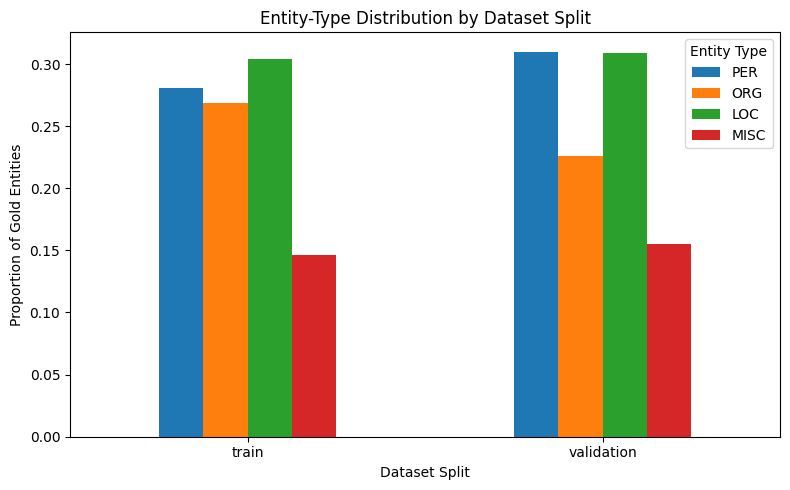

Figure saved to:
/kaggle/working/00_data_eda_split_registry/figures/entity_type_distribution.png


In [10]:
ax = entity_type_proportions.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(
    "Entity-Type Distribution by Dataset Split"
)
ax.set_xlabel("Dataset Split")
ax.set_ylabel("Proportion of Gold Entities")
ax.tick_params(
    axis="x",
    rotation=0,
)
ax.legend(
    title="Entity Type",
)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "entity_type_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(figure_path)

### Observation

The training and validation populations contain the same four entity categories with broadly similar relative frequencies.

The comparison provides a baseline description of entity-type composition before the original validation population is divided into the experimental validation and calibration subsets.

## 9. Sentence-Length Distribution

Sentence length is a simple measure of input complexity and provides useful context for later robustness and uncertainty analyses.

The distributions are compared between the training and original validation splits using both summary statistics and normalised histograms.

In [11]:
sentence_length_summary = (
    sentence_eda_df
    .groupby("split")["n_tokens"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ])
    .round(2)
)

print("Sentence-length summary:")
display(sentence_length_summary)

Sentence-length summary:


,count,mean,median,std,min,max
split,,,,,,
train,14041,14.5,10.0,11.6,1,113
validation,3250,15.8,11.0,12.6,1,109


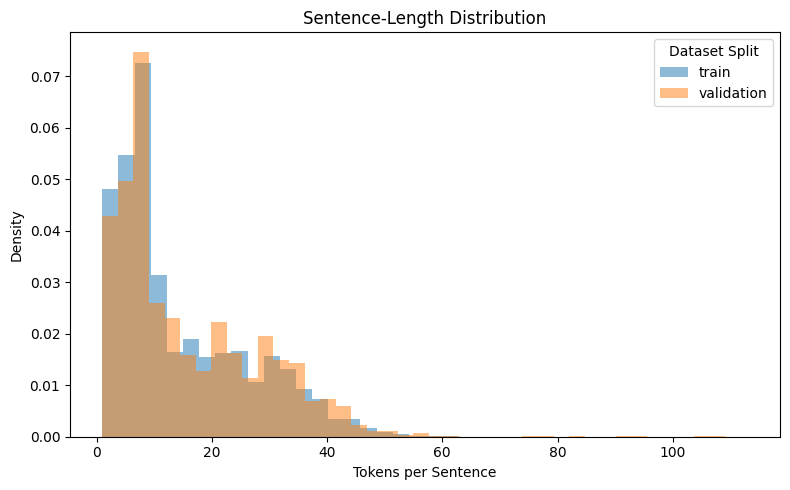

Figure saved to:
/kaggle/working/00_data_eda_split_registry/figures/sentence_length_distribution.png


In [12]:
plt.figure(
    figsize=(8, 5)
)

for split_name in [
    "train",
    "validation",
]:

    split_lengths = sentence_eda_df.loc[
        sentence_eda_df["split"] == split_name,
        "n_tokens",
    ]

    plt.hist(
        split_lengths,
        bins=40,
        density=True,
        alpha=0.5,
        label=split_name,
    )


plt.title(
    "Sentence-Length Distribution"
)
plt.xlabel(
    "Tokens per Sentence"
)
plt.ylabel(
    "Density"
)
plt.legend(
    title="Dataset Split"
)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "sentence_length_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(figure_path)

### Observation

Both development splits contain predominantly short-to-medium-length sentences with a smaller tail of longer examples.

Sentence length is retained as a descriptive variable because later uncertainty and conformal behaviour may vary with input length.

## 10. Entity Span-Length Distribution

Entity span length is directly relevant to the dissertation's boundary-level analysis.

Single-token entities have coincident start and end positions, whereas multi-token entities require distinct start and end boundaries to be identified correctly.

Span length is also important for the SpanNER-style architecture used later in the project, which enumerates candidate spans up to a maximum width of four tokens. The analysis therefore reports both the overall span-length distribution and the proportion of gold entities representable within this width.

In [13]:
span_length_counts = (
    entity_eda_df
    .groupby(
        ["split", "span_length"]
    )
    .size()
    .unstack(fill_value=0)
)


span_length_proportions = (
    span_length_counts
    .div(
        span_length_counts.sum(axis=1),
        axis=0,
    )
)


print("Gold entity span-length counts:")
display(span_length_counts)

print("\nGold entity span-length proportions:")
display(
    span_length_proportions.round(4)
)

Gold entity span-length counts:


span_length,1,2,3,4,5,6,7,8,10
split,,,,,,,,,
train,14831,7384,904,250,82,25,18,2,3
validation,3767,1857,205,83,19,3,6,0,2



Gold entity span-length proportions:


span_length,1,2,3,4,5,6,7,8,10
split,,,,,,,,,
train,0.6311,0.3142,0.0385,0.0106,0.0035,0.0011,0.0008,0.0001,0.0001
validation,0.6340,0.3125,0.0345,0.0140,0.0032,0.0005,0.0010,0.0000,0.0003


In [14]:
MAX_SPAN_WIDTH = 4


span_width_coverage = (
    entity_eda_df
    .assign(
        representable=lambda df:
        df["span_length"] <= MAX_SPAN_WIDTH
    )
    .groupby("split")
    .agg(
        total_gold_entities=(
            "representable",
            "size",
        ),
        width_leq_4_entities=(
            "representable",
            "sum",
        ),
    )
)


span_width_coverage[
    "width_leq_4_proportion"
] = (
    span_width_coverage[
        "width_leq_4_entities"
    ]
    / span_width_coverage[
        "total_gold_entities"
    ]
)


span_width_coverage[
    "width_gt_4_entities"
] = (
    span_width_coverage[
        "total_gold_entities"
    ]
    - span_width_coverage[
        "width_leq_4_entities"
    ]
)


print(
    "Gold-entity coverage under "
    "maximum span width = 4:"
)

display(
    span_width_coverage[
        [
            "total_gold_entities",
            "width_leq_4_entities",
            "width_gt_4_entities",
            "width_leq_4_proportion",
        ]
    ].round(4)
)

Gold-entity coverage under maximum span width = 4:


,total_gold_entities,width_leq_4_entities,width_gt_4_entities,width_leq_4_proportion
split,,,,
train,23499,23369,130,0.9945
validation,5942,5912,30,0.9950


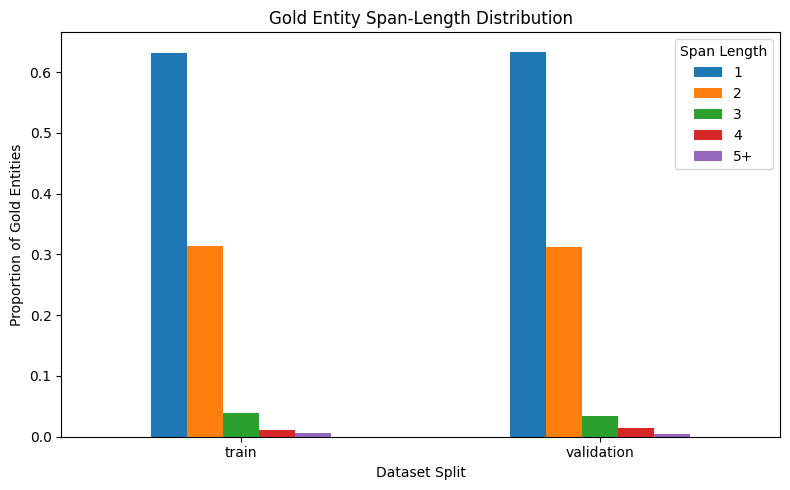

Figure saved to:
/kaggle/working/00_data_eda_split_registry/figures/entity_span_length_distribution.png


In [15]:
entity_eda_df[
    "span_length_group"
] = np.where(
    entity_eda_df["span_length"] >= 5,
    "5+",
    entity_eda_df[
        "span_length"
    ].astype(str),
)


span_group_order = [
    "1",
    "2",
    "3",
    "4",
    "5+",
]


span_group_distribution = (
    entity_eda_df
    .groupby(
        ["split", "span_length_group"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=span_group_order,
        fill_value=0,
    )
)


span_group_proportions = (
    span_group_distribution
    .div(
        span_group_distribution.sum(axis=1),
        axis=0,
    )
)


ax = span_group_proportions.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title(
    "Gold Entity Span-Length Distribution"
)
ax.set_xlabel(
    "Dataset Split"
)
ax.set_ylabel(
    "Proportion of Gold Entities"
)
ax.tick_params(
    axis="x",
    rotation=0,
)
ax.legend(
    title="Span Length"
)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "entity_span_length_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(figure_path)

### Observation

Gold entities are strongly concentrated among short spans in both development splits.

The width-4 coverage calculation quantifies the small proportion of gold entities that cannot be represented by the later SpanNER-style candidate generator. This motivates reporting both the architecture-native comparison and a matched-width sensitivity analysis later in the experimental pipeline.

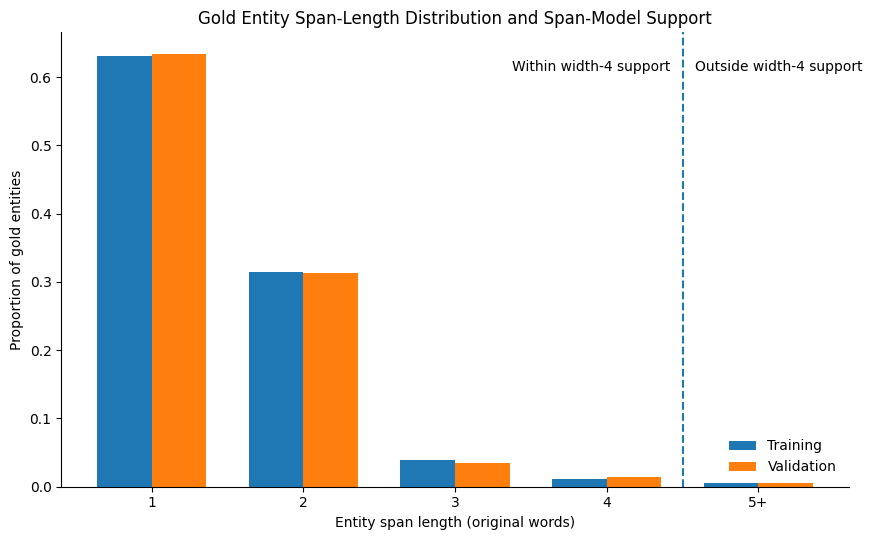

Figure saved to:
/kaggle/working/00_data_eda_split_registry/figures/entity_span_length_width4_support.png


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Existing span-length proportions from Section 10
plot_df = (
    span_group_proportions
    .loc[["train", "validation"], ["1", "2", "3", "4", "5+"]]
    .copy()
)

categories = ["1", "2", "3", "4", "5+"]
x = np.arange(len(categories))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(
    x - width / 2,
    plot_df.loc["train", categories],
    width,
    label="Training",
)

ax.bar(
    x + width / 2,
    plot_df.loc["validation", categories],
    width,
    label="Validation",
)

# Width-4 architectural boundary
ax.axvline(
    3.5,
    linestyle="--",
    linewidth=1.5,
)

ymax = ax.get_ylim()[1]

ax.text(
    3.42,
    ymax * 0.94,
    "Within width-4 support",
    ha="right",
    va="top",
    fontsize=10,
)

ax.text(
    3.58,
    ymax * 0.94,
    "Outside width-4 support",
    ha="left",
    va="top",
    fontsize=10,
)

ax.set_title(
    "Gold Entity Span-Length Distribution and Span-Model Support"
)

ax.set_xlabel(
    "Entity span length (original words)"
)

ax.set_ylabel(
    "Proportion of gold entities"
)

ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

figure_path = (
    FIGURE_DIR
    / "entity_span_length_width4_support.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(figure_path)

## 11. Entity Density per Sentence

The number of gold entities in a sentence provides a simple measure of local NER density.

Sentences containing multiple entities require several spans and boundaries to be resolved within the same context. Entity density is therefore retained as a descriptive variable for later uncertainty analysis.

In [16]:
entities_per_sentence_summary = (
    sentence_eda_df
    .groupby("split")["n_entities"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max",
    ])
    .round(2)
)


print("Entities-per-sentence summary:")
display(
    entities_per_sentence_summary
)


# Group the long tail into a single 4+ category.
sentence_eda_df[
    "entity_count_group"
] = np.select(
    [
        sentence_eda_df["n_entities"] == 0,
        sentence_eda_df["n_entities"] == 1,
        sentence_eda_df["n_entities"] == 2,
        sentence_eda_df["n_entities"] == 3,
    ],
    [
        "0",
        "1",
        "2",
        "3",
    ],
    default="4+",
)


entity_count_order = [
    "0",
    "1",
    "2",
    "3",
    "4+",
]


entity_count_distribution = (
    sentence_eda_df
    .groupby(
        ["split", "entity_count_group"]
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=entity_count_order,
        fill_value=0,
    )
)


entity_count_proportions = (
    entity_count_distribution
    .div(
        entity_count_distribution.sum(axis=1),
        axis=0,
    )
)


print(
    "\nEntity-count proportions:"
)

display(
    entity_count_proportions.round(4)
)

Entities-per-sentence summary:


,count,mean,median,std,min,max
split,,,,,,
train,14041,1.67,1.0,1.53,0,20
validation,3250,1.83,1.0,1.78,0,20



Entity-count proportions:


entity_count_group,0,1,2,3,4+
split,,,,,
train,0.2072,0.3558,0.2105,0.1014,0.1251
validation,0.1985,0.3157,0.2422,0.1062,0.1375


## 12. EDA Summary

The exploratory analysis establishes the following features of the CoNLL-2003 development data:

- the training and original validation populations contain the same four NER entity types with broadly comparable class composition;
- sentence lengths are right-skewed, with most examples concentrated among shorter and medium-length sentences;
- gold entities are dominated by short spans;
- the width-4 analysis quantifies the proportion of gold entities representable by the later SpanNER-style candidate generator;
- most sentences contain relatively few entities, with a smaller tail of entity-dense examples.

These properties provide context for the later architecture, boundary-error and uncertainty analyses.

No decisions in this EDA stage use the official CoNLL-2003 test split.

The next stage creates and audits the fixed validation and calibration populations used throughout the experimental pipeline.

## 13. Create the Validation and Parent-Calibration Populations

The original 3,250-sentence CoNLL-2003 validation split is divided into two equally sized experimental populations:

- **Validation:** 1,625 sentences, used for model development, validation and model-selection decisions.
- **Parent calibration:** 1,625 sentences, reserved from those model-selection decisions and used as the source of the later probability- and conformal-calibration subsets.

The split is created deterministically using Hugging Face `train_test_split` with:

- `test_size = 0.5`;
- `shuffle = True`;
- random seed `42`.

Each original validation sentence is assigned a permanent `source_index` before splitting. This index allows every experimental row to be traced back to its position in the original CoNLL-2003 validation split.

No model predictions, confidence values, uncertainty estimates or test-set information are used to construct this split.

### 13.1 Define Sentence-Identity Utilities

Two exact SHA-256 identifiers are used for auditing:

- `sentence_hash`: hashes the ordered token sequence only;
- `labeled_sentence_hash`: hashes both the ordered token sequence and its NER label sequence.

The token-only hash is used to identify repeated sentence text. The labeled hash additionally determines whether repeated token sequences carry the same NER annotation.

Aggregate hashes over ordered sentence hashes are also calculated and saved as reproducibility identifiers for each population.

In [17]:
def create_sentence_hash(tokens):
    """
    Create a SHA-256 hash of the exact ordered token sequence.
    """

    payload = json.dumps(
        list(tokens),
        ensure_ascii=False,
        separators=(",", ":"),
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()


def create_labeled_sentence_hash(
    tokens,
    ner_tags,
):
    """
    Create a SHA-256 hash of the exact token sequence
    together with its NER label sequence.
    """

    payload = {
        "tokens": list(tokens),
        "ner_tags": [
            int(tag)
            for tag in ner_tags
        ],
    }

    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        separators=(",", ":"),
        sort_keys=True,
    )

    return hashlib.sha256(
        encoded.encode("utf-8")
    ).hexdigest()


def sha256_from_lines(lines):
    """
    Create one aggregate SHA-256 hash from
    an ordered sequence of strings.
    """

    return hashlib.sha256(
        "\n".join(lines).encode("utf-8")
    ).hexdigest()


print("Sentence-identity utilities created.")

Sentence-identity utilities created.


### 13.2 Create the 50:50 Validation/Parent-Calibration Split

A permanent `source_index` is first attached to every sentence in the original CoNLL-2003 validation split.

The deterministic 50:50 split is then generated using the fixed split seed.

The two resulting populations must:

- contain exactly 1,625 sentences each;
- contain disjoint source indices;
- together reconstruct all 3,250 original validation rows.

In [18]:
validation_source = (
    original_validation_dataset
    .add_column(
        "source_index",
        list(
            range(
                len(
                    original_validation_dataset
                )
            )
        ),
    )
)


development_split = (
    validation_source
    .train_test_split(
        test_size=0.5,
        seed=SPLIT_SEED,
        shuffle=True,
    )
)


validation_population = (
    development_split["train"]
)

parent_calibration_population = (
    development_split["test"]
)


# Structural integrity checks

assert (
    len(validation_population)
    == TARGET_VALIDATION
)

assert (
    len(parent_calibration_population)
    == TARGET_PARENT_CALIBRATION
)


validation_source_indices = set(
    int(index)
    for index
    in validation_population[
        "source_index"
    ]
)

parent_calibration_source_indices = set(
    int(index)
    for index
    in parent_calibration_population[
        "source_index"
    ]
)


assert (
    validation_source_indices
    .isdisjoint(
        parent_calibration_source_indices
    )
)

assert (
    validation_source_indices
    | parent_calibration_source_indices
    == set(
        range(
            len(
                original_validation_dataset
            )
        )
    )
)


population_summary = pd.DataFrame({
    "Population": [
        "Validation",
        "Parent calibration",
    ],
    "Sentences": [
        len(validation_population),
        len(
            parent_calibration_population
        ),
    ],
    "Role": [
        (
            "Model development, validation "
            "and model selection"
        ),
        (
            "Source of probability and "
            "conformal calibration subsets"
        ),
    ],
})


print(
    "Validation/parent-calibration split created successfully."
)

display(population_summary)

Validation/parent-calibration split created successfully.


,Population,Sentences,Role
0,Validation,1625,"Model development, validation and model selection"
1,Parent calibration,1625,Source of probability and conformal calibratio...


### 13.3 Build the Population Registries

For each sentence, the registry records:

- its original CoNLL validation `source_index`;
- its position within the experimental population;
- exact token and labeled-sentence hashes;
- token count;
- number of gold entity spans.

Population identities are calculated directly from the split produced in this run. They are not compared against hard-coded results from an earlier execution.

These calculated identities are later saved so that downstream notebooks can verify that they are using the same frozen populations.

In [19]:
def build_population_registry(
    split_data,
    population_name,
):
    """
    Build a sentence-level registry and calculate
    reproducibility identifiers for one population.
    """

    records = []

    ordered_token_hashes = []
    ordered_labeled_hashes = []

    total_tokens = 0
    total_gold_spans = 0

    for local_index, example in enumerate(
        split_data
    ):

        tokens = list(
            example["tokens"]
        )

        ner_tags = [
            int(tag)
            for tag
            in example["ner_tags"]
        ]

        gold_spans = bio_tags_to_spans(
            ner_tags
        )

        token_hash = create_sentence_hash(
            tokens
        )

        labeled_hash = (
            create_labeled_sentence_hash(
                tokens,
                ner_tags,
            )
        )

        source_index = int(
            example["source_index"]
        )

        ordered_token_hashes.append(
            token_hash
        )

        ordered_labeled_hashes.append(
            labeled_hash
        )

        total_tokens += len(tokens)

        total_gold_spans += len(
            gold_spans
        )

        records.append({
            "population": (
                population_name
            ),
            "source_split": (
                "validation"
            ),
            "source_index": (
                source_index
            ),
            "population_local_index": (
                local_index
            ),
            "canonical_sentence_id": (
                f"validation::{source_index}"
            ),
            "dataset_id": str(
                example["id"]
            ),
            "sentence_hash": (
                token_hash
            ),
            "labeled_sentence_hash": (
                labeled_hash
            ),
            "n_tokens": len(tokens),
            "n_entities": len(
                gold_spans
            ),
        })


    registry = pd.DataFrame(
        records
    )


    identity = {
        "sentences": (
            len(registry)
        ),
        "tokens": int(
            registry[
                "n_tokens"
            ].sum()
        ),
        "gold_spans": int(
            registry[
                "n_entities"
            ].sum()
        ),
        "aggregate_token_hash": (
            sha256_from_lines(
                ordered_token_hashes
            )
        ),
        "aggregate_labeled_hash": (
            sha256_from_lines(
                ordered_labeled_hashes
            )
        ),
    }


    return registry, identity

In [20]:
validation_registry_df, validation_identity = (
    build_population_registry(
        validation_population,
        "validation",
    )
)


parent_calibration_registry_df, parent_calibration_identity = (
    build_population_registry(
        parent_calibration_population,
        "parent_calibration",
    )
)


identity_summary_df = pd.DataFrame([
    {
        "Population": "Validation",
        "Sentences": (
            validation_identity[
                "sentences"
            ]
        ),
        "Tokens": (
            validation_identity[
                "tokens"
            ]
        ),
        "Gold Spans": (
            validation_identity[
                "gold_spans"
            ]
        ),
        "Aggregate Token Hash": (
            validation_identity[
                "aggregate_token_hash"
            ]
        ),
    },
    {
        "Population": (
            "Parent calibration"
        ),
        "Sentences": (
            parent_calibration_identity[
                "sentences"
            ]
        ),
        "Tokens": (
            parent_calibration_identity[
                "tokens"
            ]
        ),
        "Gold Spans": (
            parent_calibration_identity[
                "gold_spans"
            ]
        ),
        "Aggregate Token Hash": (
            parent_calibration_identity[
                "aggregate_token_hash"
            ]
        ),
    },
])


print(
    "Population identities calculated:"
)

display(identity_summary_df)

Population identities calculated:


,Population,Sentences,Tokens,Gold Spans,Aggregate Token Hash
0,Validation,1625,26021,3011,dccc5ec8dfba59e998153fa5e81fbaee3a6895c59f9ade...
1,Parent calibration,1625,25341,2931,6921c7fa83233ba35eb645e6047e37bfd03cad164fd75e...


### 13.4 Audit Exact Content Overlap

The source indices of the validation and parent-calibration populations are strictly disjoint. However, different CoNLL rows may contain identical token sequences.

Two forms of exact content overlap are therefore reported:

1. **token-identical overlap** — the same ordered token sequence occurs in both populations;
2. **token-and-label-identical overlap** — both the token sequence and NER annotation are identical.

These checks are descriptive audits only. They do not alter the deterministic experimental split.

The audit detects exact duplicates only. Near-duplicate, templated or semantically equivalent sentences are not identified by these hashes and remain a limitation of the split audit.

In [21]:
validation_token_hashes = set(
    validation_registry_df[
        "sentence_hash"
    ]
)

parent_token_hashes = set(
    parent_calibration_registry_df[
        "sentence_hash"
    ]
)


validation_labeled_hashes = set(
    validation_registry_df[
        "labeled_sentence_hash"
    ]
)

parent_labeled_hashes = set(
    parent_calibration_registry_df[
        "labeled_sentence_hash"
    ]
)


shared_token_hashes = (
    validation_token_hashes
    & parent_token_hashes
)

shared_labeled_hashes = (
    validation_labeled_hashes
    & parent_labeled_hashes
)


validation_rows_with_shared_text = (
    validation_registry_df[
        "sentence_hash"
    ]
    .isin(
        shared_token_hashes
    )
    .sum()
)

parent_rows_with_shared_text = (
    parent_calibration_registry_df[
        "sentence_hash"
    ]
    .isin(
        shared_token_hashes
    )
    .sum()
)


validation_rows_with_shared_labels = (
    validation_registry_df[
        "labeled_sentence_hash"
    ]
    .isin(
        shared_labeled_hashes
    )
    .sum()
)

parent_rows_with_shared_labels = (
    parent_calibration_registry_df[
        "labeled_sentence_hash"
    ]
    .isin(
        shared_labeled_hashes
    )
    .sum()
)


content_overlap_summary = pd.DataFrame({
    "Overlap Type": [
        "Identical token sequence",
        (
            "Identical token sequence "
            "and NER labels"
        ),
    ],
    "Shared Unique Hashes": [
        len(
            shared_token_hashes
        ),
        len(
            shared_labeled_hashes
        ),
    ],
    "Validation Rows Involved": [
        int(
            validation_rows_with_shared_text
        ),
        int(
            validation_rows_with_shared_labels
        ),
    ],
    "Parent-Calibration Rows Involved": [
        int(
            parent_rows_with_shared_text
        ),
        int(
            parent_rows_with_shared_labels
        ),
    ],
})


print(
    "Exact validation/calibration content-overlap audit:"
)

display(content_overlap_summary)


print(
    "\nSource-index overlap:",
    len(
        validation_source_indices
        & parent_calibration_source_indices
    ),
)

Exact validation/calibration content-overlap audit:


,Overlap Type,Shared Unique Hashes,Validation Rows Involved,Parent-Calibration Rows Involved
0,Identical token sequence,56,93,96
1,Identical token sequence and NER labels,55,92,94



Source-index overlap: 0


### 13.5 Inspect the Exact-Overlap Groups

A compact summary of repeated token sequences is shown to help distinguish isolated short repetitions from larger duplicate groups.

The full sentence text is not required for constructing the split and is therefore not saved in the permanent registry.

In [22]:
overlap_group_summary = (
    pd.concat(
        [
            validation_registry_df[
                [
                    "population",
                    "sentence_hash",
                    "labeled_sentence_hash",
                    "n_tokens",
                ]
            ],
            parent_calibration_registry_df[
                [
                    "population",
                    "sentence_hash",
                    "labeled_sentence_hash",
                    "n_tokens",
                ]
            ],
        ],
        ignore_index=True,
    )
    .loc[
        lambda df:
        df["sentence_hash"].isin(
            shared_token_hashes
        )
    ]
    .groupby(
        "sentence_hash",
        as_index=False,
    )
    .agg(
        total_rows=(
            "population",
            "size",
        ),
        populations=(
            "population",
            lambda values:
            ", ".join(
                sorted(
                    set(values)
                )
            ),
        ),
        n_tokens=(
            "n_tokens",
            "first",
        ),
        unique_labelings=(
            "labeled_sentence_hash",
            "nunique",
        ),
    )
    .sort_values(
        [
            "n_tokens",
            "total_rows",
        ],
        ascending=[
            False,
            False,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


print(
    "Exact token-overlap groups:"
)

display(
    overlap_group_summary.head(20)
)

Exact token-overlap groups:


,sentence_hash,total_rows,populations,n_tokens,unique_labelings
0,f958e21625ee1a1db4799e419057436e3f26df5f0ec337...,2,"parent_calibration, validation",37,1
1,119f1d8224ec631f802a46424ea869ecf08258e9a0b6b7...,2,"parent_calibration, validation",27,1
2,26eadef50f933239e455f334e9acba4da816db5b81c525...,2,"parent_calibration, validation",9,1
3,c2bbb22341668fb5cd048d24373bc21ee3f60533d19783...,2,"parent_calibration, validation",8,1
4,2dae2d9b04fdcc0e5425500fd3b6642a6df5ce1d63329b...,2,"parent_calibration, validation",7,1
5,08cd6bb44dd483447c1900d90d2d86e8959dc93c1f5a36...,2,"parent_calibration, validation",6,1
6,79290e9d352f244f31e09d99ebaa4d340b72083525f869...,2,"parent_calibration, validation",6,1
7,83c0c99431c4825c3fe4668ba2a46ca65cd3a7ea59490a...,2,"parent_calibration, validation",5,1
8,16d543441e1c2b2dd159ee657843dc9b8110feaa2d03e9...,4,"parent_calibration, validation",4,1
9,9b825f568eff91079b1ac3a039f3ef12e46f04f660215c...,3,"parent_calibration, validation",4,2


## 14. Create the Probability- and Conformal-Calibration Subsets

Only the parent-calibration population is subdivided further.

The target sizes are:

- **Probability calibration:** 975 sentences;
- **Conformal calibration:** 650 sentences.

To prevent exact duplicate sentence text from crossing between these two calibration subsets, rows sharing the same `sentence_hash` are treated as an indivisible group.

The grouped split is deterministic:

1. rows are grouped by exact token-sequence hash;
2. groups are ordered by hash;
3. the group order is permuted using `CALIBRATION_SUBSPLIT_SEED = 42`;
4. a subset-sum procedure selects complete groups totalling exactly 975 sentences;
5. the remaining groups form the 650-sentence conformal-calibration subset.

No predictions, labels, model errors, confidence values or uncertainty estimates are used when assigning the calibration subsets.

### 14.1 Prepare the Frozen Parent-Calibration Registry

The exact historical order of the parent-calibration population is preserved because it is useful for reproducibility and for comparison with earlier saved outputs.

In [23]:
parent_calibration_working_df = (
    parent_calibration_registry_df
    .copy()
    .reset_index(drop=True)
)


parent_calibration_working_df[
    "parent_calibration_order"
] = np.arange(
    len(
        parent_calibration_working_df
    ),
    dtype=int,
)


assert (
    len(
        parent_calibration_working_df
    )
    == TARGET_PARENT_CALIBRATION
)


# Verify that the working copy preserves
# the population created in Section 13.
working_parent_hash = sha256_from_lines(
    parent_calibration_working_df[
        "sentence_hash"
    ]
    .astype(str)
    .tolist()
)


assert (
    working_parent_hash
    == parent_calibration_identity[
        "aggregate_token_hash"
    ]
)


parent_calibration_summary_df = pd.DataFrame({
    "Measure": [
        "Sentences",
        "Tokens",
        "Gold spans",
        "Unique token sequences",
    ],
    "Value": [
        len(
            parent_calibration_working_df
        ),
        int(
            parent_calibration_working_df[
                "n_tokens"
            ].sum()
        ),
        int(
            parent_calibration_working_df[
                "n_entities"
            ].sum()
        ),
        int(
            parent_calibration_working_df[
                "sentence_hash"
            ].nunique()
        ),
    ],
})


print(
    "Parent-calibration population:"
)

display(
    parent_calibration_summary_df
)

Parent-calibration population:


,Measure,Value
0,Sentences,1625
1,Tokens,25341
2,Gold spans,2931
3,Unique token sequences,1561


### 14.2 Duplicate-Safe 975/650 Calibration Subdivision

In [24]:
sentence_group_df = (
    parent_calibration_working_df
    .groupby(
        "sentence_hash",
        sort=True,
    )
    .agg(
        group_size=(
            "canonical_sentence_id",
            "size",
        )
    )
    .reset_index()
)


sentence_group_df = (
    sentence_group_df
    .sort_values(
        "sentence_hash",
        kind="stable",
    )
    .reset_index(drop=True)
)


# Deterministically permute the duplicate groups.
rng = np.random.default_rng(
    CALIBRATION_SUBSPLIT_SEED
)

group_permutation = rng.permutation(
    len(sentence_group_df)
)

sentence_group_df = (
    sentence_group_df
    .iloc[group_permutation]
    .reset_index(drop=True)
)


sentence_group_df[
    "split_generation_group_order"
] = np.arange(
    len(sentence_group_df),
    dtype=int,
)


# Select complete groups totalling exactly 975 sentences.

target_probability_count = (
    TARGET_PROBABILITY_CALIBRATION
)


reachable = np.zeros(
    target_probability_count + 1,
    dtype=bool,
)

previous_total = np.full(
    target_probability_count + 1,
    -1,
    dtype=int,
)

previous_group = np.full(
    target_probability_count + 1,
    -1,
    dtype=int,
)

reachable[0] = True


for group_position, row in (
    sentence_group_df.iterrows()
):

    group_size = int(
        row["group_size"]
    )

    for current_total in range(
        target_probability_count
        - group_size,
        -1,
        -1,
    ):

        if not reachable[
            current_total
        ]:
            continue

        new_total = (
            current_total
            + group_size
        )

        if not reachable[
            new_total
        ]:
            reachable[
                new_total
            ] = True

            previous_total[
                new_total
            ] = current_total

            previous_group[
                new_total
            ] = group_position


if not reachable[
    target_probability_count
]:
    raise RuntimeError(
        "Could not construct an exact "
        "975-sentence grouped calibration split."
    )


# Reconstruct the selected duplicate groups.
selected_group_positions = []

current_total = (
    target_probability_count
)


while current_total > 0:

    group_position = int(
        previous_group[
            current_total
        ]
    )

    if group_position < 0:
        raise RuntimeError(
            "Failed to reconstruct the "
            "grouped calibration assignment."
        )

    selected_group_positions.append(
        group_position
    )

    current_total = int(
        previous_total[
            current_total
        ]
    )


probability_sentence_hashes = set(
    sentence_group_df.loc[
        selected_group_positions,
        "sentence_hash",
    ]
)


sentence_group_df[
    "experiment_split"
] = np.where(
    sentence_group_df[
        "sentence_hash"
    ].isin(
        probability_sentence_hashes
    ),
    "probability_calibration",
    "conformal_calibration",
)


print(
    "Duplicate-safe calibration subdivision created."
)

Duplicate-safe calibration subdivision created.


### 14.3 Map Group Assignments Back to Sentences

Each sentence inherits the calibration assignment of its exact token-sequence group.

The registry is then returned to the original parent-calibration order and a local index is assigned within each final calibration subset.

In [25]:
group_assignment_map = (
    sentence_group_df
    .set_index(
        "sentence_hash"
    )[
        "experiment_split"
    ]
)


group_order_map = (
    sentence_group_df
    .set_index(
        "sentence_hash"
    )[
        "split_generation_group_order"
    ]
)


group_size_map = (
    sentence_group_df
    .set_index(
        "sentence_hash"
    )[
        "group_size"
    ]
)


parent_calibration_working_df[
    "experiment_split"
] = (
    parent_calibration_working_df[
        "sentence_hash"
    ].map(
        group_assignment_map
    )
)


parent_calibration_working_df[
    "split_generation_group_order"
] = (
    parent_calibration_working_df[
        "sentence_hash"
    ].map(
        group_order_map
    )
)


parent_calibration_working_df[
    "sentence_hash_group_size"
] = (
    parent_calibration_working_df[
        "sentence_hash"
    ].map(
        group_size_map
    )
)


parent_calibration_working_df = (
    parent_calibration_working_df
    .sort_values(
        "parent_calibration_order",
        kind="stable",
    )
    .reset_index(drop=True)
)


parent_calibration_working_df[
    "experiment_local_index"
] = (
    parent_calibration_working_df
    .groupby(
        "experiment_split",
        sort=False,
    )
    .cumcount()
)


probability_registry_df = (
    parent_calibration_working_df.loc[
        parent_calibration_working_df[
            "experiment_split"
        ].eq(
            "probability_calibration"
        )
    ]
    .copy()
    .reset_index(drop=True)
)


conformal_registry_df = (
    parent_calibration_working_df.loc[
        parent_calibration_working_df[
            "experiment_split"
        ].eq(
            "conformal_calibration"
        )
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "Probability-calibration sample:"
)

display(
    probability_registry_df[
        [
            "canonical_sentence_id",
            "source_index",
            "n_tokens",
            "sentence_hash_group_size",
        ]
    ].head()
)


print(
    "\nConformal-calibration sample:"
)

display(
    conformal_registry_df[
        [
            "canonical_sentence_id",
            "source_index",
            "n_tokens",
            "sentence_hash_group_size",
        ]
    ].head()
)

Probability-calibration sample:


,canonical_sentence_id,source_index,n_tokens,sentence_hash_group_size
0,validation::1495,1495,34,1
1,validation::1412,1412,11,1
2,validation::78,78,17,1
3,validation::974,974,26,1
4,validation::622,622,7,1



Conformal-calibration sample:


,canonical_sentence_id,source_index,n_tokens,sentence_hash_group_size
0,validation::129,129,2,2
1,validation::2029,2029,9,1
2,validation::454,454,4,1
3,validation::772,772,19,1
4,validation::1624,1624,23,1


### 14.4 Verify the Calibration Subdivision

The final calibration subsets must satisfy the following structural conditions:

- probability calibration contains exactly 975 sentences;
- conformal calibration contains exactly 650 sentences;
- their source indices are disjoint;
- together they reconstruct the complete parent-calibration population;
- no exact token sequence crosses between the two calibration subsets;
- the original validation population remains source-index disjoint from the complete parent-calibration population.

Token counts, gold-span counts and hashes are reported as outcomes of the generated split rather than compared against values known from previous runs.

In [26]:
# Size checks

assert (
    len(probability_registry_df)
    == TARGET_PROBABILITY_CALIBRATION
)

assert (
    len(conformal_registry_df)
    == TARGET_CONFORMAL_CALIBRATION
)


probability_indices = set(
    probability_registry_df[
        "source_index"
    ].astype(int)
)

conformal_indices = set(
    conformal_registry_df[
        "source_index"
    ].astype(int)
)

parent_calibration_indices = set(
    parent_calibration_registry_df[
        "source_index"
    ].astype(int)
)

validation_indices = set(
    validation_registry_df[
        "source_index"
    ].astype(int)
)


# Index-level partition checks

assert probability_indices.isdisjoint(
    conformal_indices
)

assert (
    probability_indices
    | conformal_indices
    == parent_calibration_indices
)

assert validation_indices.isdisjoint(
    parent_calibration_indices
)

assert (
    validation_indices
    | parent_calibration_indices
    == set(
        range(
            len(
                original_validation_dataset
            )
        )
    )
)


# Exact duplicate-text leakage check between
# probability and conformal calibration.

probability_token_hashes = set(
    probability_registry_df[
        "sentence_hash"
    ]
)

conformal_token_hashes = set(
    conformal_registry_df[
        "sentence_hash"
    ]
)


assert (
    probability_token_hashes
    .isdisjoint(
        conformal_token_hashes
    )
)


# The stronger token+label identity check must
# therefore also be disjoint.
probability_labeled_hashes = set(
    probability_registry_df[
        "labeled_sentence_hash"
    ]
)

conformal_labeled_hashes = set(
    conformal_registry_df[
        "labeled_sentence_hash"
    ]
)


assert (
    probability_labeled_hashes
    .isdisjoint(
        conformal_labeled_hashes
    )
)


# Verify that parent-calibration ordering was preserved.

reconstructed_parent_hash = (
    sha256_from_lines(
        parent_calibration_working_df[
            "sentence_hash"
        ]
        .astype(str)
        .tolist()
    )
)


assert (
    reconstructed_parent_hash
    == parent_calibration_identity[
        "aggregate_token_hash"
    ]
)


calibration_verification_df = pd.DataFrame({
    "Check": [
        "Validation / parent source-index overlap",
        "Probability-calibration sentences",
        "Conformal-calibration sentences",
        "Probability / conformal source overlap",
        (
            "Exact token sequences crossing "
            "probability / conformal"
        ),
        (
            "Exact labeled sequences crossing "
            "probability / conformal"
        ),
        "Parent-calibration reconstruction",
    ],
    "Result": [
        0,
        len(
            probability_registry_df
        ),
        len(
            conformal_registry_df
        ),
        len(
            probability_indices
            & conformal_indices
        ),
        len(
            probability_token_hashes
            & conformal_token_hashes
        ),
        len(
            probability_labeled_hashes
            & conformal_labeled_hashes
        ),
        "PASSED",
    ],
})


print(
    "Calibration subdivision verification:"
)

display(
    calibration_verification_df
)

Calibration subdivision verification:


,Check,Result
0,Validation / parent source-index overlap,0
1,Probability-calibration sentences,975
2,Conformal-calibration sentences,650
3,Probability / conformal source overlap,0
4,Exact token sequences crossing probability / c...,0
5,Exact labeled sequences crossing probability /...,0
6,Parent-calibration reconstruction,PASSED


### 14.5 Audit Validation-to-Calibration Content Overlap

The earlier validation/parent-calibration audit is now decomposed by final calibration subset.

This reports how many exact token sequences and exact token-plus-label sequences are shared between:

- validation and probability calibration;
- validation and conformal calibration;
- probability and conformal calibration.

These overlaps are reported for transparency and do not alter the experimental assignments.

In [27]:
def overlap_counts(
    left_df,
    right_df,
):
    """
    Count exact token and token+label overlap
    between two registry tables.
    """

    left_token_hashes = set(
        left_df["sentence_hash"]
    )

    right_token_hashes = set(
        right_df["sentence_hash"]
    )

    left_labeled_hashes = set(
        left_df[
            "labeled_sentence_hash"
        ]
    )

    right_labeled_hashes = set(
        right_df[
            "labeled_sentence_hash"
        ]
    )


    shared_tokens = (
        left_token_hashes
        & right_token_hashes
    )

    shared_labeled = (
        left_labeled_hashes
        & right_labeled_hashes
    )


    return {
        "shared_token_sequences": (
            len(shared_tokens)
        ),
        "shared_labeled_sequences": (
            len(shared_labeled)
        ),
    }


validation_probability_overlap = (
    overlap_counts(
        validation_registry_df,
        probability_registry_df,
    )
)

validation_conformal_overlap = (
    overlap_counts(
        validation_registry_df,
        conformal_registry_df,
    )
)

probability_conformal_overlap = (
    overlap_counts(
        probability_registry_df,
        conformal_registry_df,
    )
)


final_overlap_audit_df = pd.DataFrame([
    {
        "Comparison": (
            "Validation vs probability calibration"
        ),
        **validation_probability_overlap,
    },
    {
        "Comparison": (
            "Validation vs conformal calibration"
        ),
        **validation_conformal_overlap,
    },
    {
        "Comparison": (
            "Probability vs conformal calibration"
        ),
        **probability_conformal_overlap,
    },
])


print(
    "Final exact-content overlap audit:"
)

display(
    final_overlap_audit_df
)

Final exact-content overlap audit:


,Comparison,shared_token_sequences,shared_labeled_sequences
0,Validation vs probability calibration,34,34
1,Validation vs conformal calibration,22,21
2,Probability vs conformal calibration,0,0


In [28]:
# Identify exact token sequences that appear with
# more than one NER labeling across validation and
# parent calibration.

combined_overlap_registry = pd.concat(
    [
        validation_registry_df.assign(
            split_name="validation"
        ),
        parent_calibration_registry_df.assign(
            split_name="parent_calibration"
        ),
    ],
    ignore_index=True,
)


label_disagreement_hashes = (
    combined_overlap_registry
    .loc[
        combined_overlap_registry[
            "sentence_hash"
        ].isin(shared_token_hashes)
    ]
    .groupby("sentence_hash")[
        "labeled_sentence_hash"
    ]
    .nunique()
)


label_disagreement_hashes = set(
    label_disagreement_hashes[
        label_disagreement_hashes > 1
    ].index
)


print(
    "Shared token sequences with "
    "different NER labelings:",
    len(label_disagreement_hashes),
)

for sentence_hash in label_disagreement_hashes:

    rows = (
        combined_overlap_registry.loc[
            combined_overlap_registry[
                "sentence_hash"
            ].eq(sentence_hash)
        ]
        .sort_values(
            ["split_name", "source_index"]
        )
    )

    print("\n" + "=" * 80)
    print(
        "Sentence hash:",
        sentence_hash,
    )

    for _, row in rows.iterrows():

        source_index = int(
            row["source_index"]
        )

        example = (
            original_validation_dataset[
                source_index
            ]
        )

        tokens = list(
            example["tokens"]
        )

        ner_tags = [
            id2label[int(tag)]
            for tag
            in example["ner_tags"]
        ]

        print(
            f"\nPopulation: "
            f"{row['split_name']}"
        )

        print(
            "Source index:",
            source_index,
        )

        print(
            "Tokens:"
        )
        print(
            " ".join(tokens)
        )

        print(
            "NER labels:"
        )
        print(
            ner_tags
        )

Shared token sequences with different NER labelings: 1

Sentence hash: 9b825f568eff91079b1ac3a039f3ef12e46f04f660215c8ed861fccfcbb591bc

Population: parent_calibration
Source index: 1698
Tokens:
BIRMINGHAM , England 1996-08-31
NER labels:
['B-LOC', 'O', 'B-LOC', 'O']

Population: parent_calibration
Source index: 1818
Tokens:
BIRMINGHAM , England 1996-08-31
NER labels:
['B-LOC', 'O', 'B-LOC', 'O']

Population: validation
Source index: 1728
Tokens:
BIRMINGHAM , England 1996-08-31
NER labels:
['B-ORG', 'O', 'B-LOC', 'O']


### Content-Overlap Audit Summary

The validation and parent-calibration populations are fully disjoint by source index, but exact repeated sentence text exists across the two populations.

The audit identified 56 distinct token sequences shared between validation and parent calibration. Of these, 55 also carry identical NER label sequences, while one repeated token sequence appears with more than one NER annotation.

After subdividing parent calibration, 34 exact token sequences are shared between validation and probability calibration and 22 between validation and conformal calibration.

Crucially, no exact token sequence or token-plus-label sequence crosses between the probability- and conformal-calibration subsets.

These repetitions are retained because they arise from different source rows in the original CoNLL-2003 validation split and the experimental partitions remain index-disjoint. Exact hashing does not detect near-duplicate or semantically equivalent sentences, which is retained as a limitation of the split audit.

## 15. Build the Final Experimental Split Registry

The validation, probability-calibration and conformal-calibration assignments are now combined into one permanent row-level registry.

Each original CoNLL-2003 validation sentence appears exactly once and is assigned one experimental role:

- `validation`;
- `probability_calibration`;
- `conformal_calibration`.

The registry preserves the original CoNLL validation-row index so that downstream notebooks can reconstruct each population directly from the source dataset without performing any additional random splitting.

In [29]:
split_order = [
    "validation",
    "probability_calibration",
    "conformal_calibration",
]


# Prepare the validation population.

validation_final_df = (
    validation_registry_df
    .copy()
)

validation_final_df[
    "experiment_split"
] = "validation"

validation_final_df[
    "experiment_local_index"
] = validation_final_df[
    "population_local_index"
].astype(int)

# These fields apply only to the subdivision
# of the parent-calibration population.
validation_final_df[
    "parent_calibration_order"
] = np.nan

validation_final_df[
    "split_generation_group_order"
] = np.nan

validation_final_df[
    "sentence_hash_group_size"
] = np.nan


# Prepare the two calibration populations.

calibration_final_df = (
    parent_calibration_working_df
    .copy()
)


# Combine all three experimental populations.

split_registry = pd.concat(
    [
        validation_final_df,
        calibration_final_df,
    ],
    ignore_index=True,
    sort=False,
)


# Keep only fields needed for provenance,
# reproducibility and downstream loading.
registry_columns = [
    "source_split",
    "source_index",
    "canonical_sentence_id",
    "dataset_id",
    "sentence_hash",
    "labeled_sentence_hash",
    "experiment_split",
    "experiment_local_index",
    "parent_calibration_order",
    "split_generation_group_order",
    "sentence_hash_group_size",
    "n_tokens",
    "n_entities",
]


split_registry = (
    split_registry[
        registry_columns
    ]
    .copy()
)


# Order the registry by experimental role and
# local order within each population.
split_registry[
    "experiment_split"
] = pd.Categorical(
    split_registry[
        "experiment_split"
    ],
    categories=split_order,
    ordered=True,
)


split_registry = (
    split_registry
    .sort_values(
        [
            "experiment_split",
            "experiment_local_index",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# Structural integrity checks.

final_split_counts = (
    split_registry[
        "experiment_split"
    ]
    .value_counts(sort=False)
    .reindex(split_order)
)


assert (
    final_split_counts[
        "validation"
    ]
    == TARGET_VALIDATION
)

assert (
    final_split_counts[
        "probability_calibration"
    ]
    == TARGET_PROBABILITY_CALIBRATION
)

assert (
    final_split_counts[
        "conformal_calibration"
    ]
    == TARGET_CONFORMAL_CALIBRATION
)


assert (
    len(split_registry)
    == len(
        original_validation_dataset
    )
)

assert (
    split_registry[
        "source_index"
    ].is_unique
)

assert (
    set(
        split_registry[
            "source_index"
        ].astype(int)
    )
    == set(
        range(
            len(
                original_validation_dataset
            )
        )
    )
)


print(
    "Final experimental split registry created."
)

display(
    final_split_counts
    .rename("sentences")
    .to_frame()
)

Final experimental split registry created.


,sentences
experiment_split,
validation,1625
probability_calibration,975
conformal_calibration,650


### 15.1 Summarise the Final Experimental Populations

The final populations are compared descriptively using sentence length, entity density and gold entity-type composition.

These summaries are diagnostic only. They are not used to modify or rebalance the split assignments.

In [30]:
final_sentence_summary = (
    split_registry
    .groupby(
        "experiment_split",
        observed=True,
    )
    .agg(
        sentences=(
            "source_index",
            "count",
        ),
        total_tokens=(
            "n_tokens",
            "sum",
        ),
        mean_tokens=(
            "n_tokens",
            "mean",
        ),
        median_tokens=(
            "n_tokens",
            "median",
        ),
        total_gold_entities=(
            "n_entities",
            "sum",
        ),
        mean_entities=(
            "n_entities",
            "mean",
        ),
        median_entities=(
            "n_entities",
            "median",
        ),
    )
    .reindex(split_order)
    .round(2)
)


print(
    "Final experimental population summary:"
)

display(
    final_sentence_summary
)

Final experimental population summary:


,sentences,total_tokens,mean_tokens,median_tokens,total_gold_entities,mean_entities,median_entities
experiment_split,,,,,,,
validation,1625,26021,16.01,11.0,3011,1.85,1.0
probability_calibration,975,15726,16.13,11.0,1756,1.80,1.0
conformal_calibration,650,9615,14.79,10.0,1175,1.81,1.0


In [31]:
final_validation_entities = (
    validation_entity_df
    .merge(
        split_registry[
            [
                "source_index",
                "experiment_split",
            ]
        ],
        left_on="sentence_index",
        right_on="source_index",
        how="left",
        validate="many_to_one",
    )
)


assert (
    final_validation_entities[
        "experiment_split"
    ].notna().all()
)


final_entity_counts = (
    final_validation_entities
    .groupby(
        [
            "experiment_split",
            "entity_type",
        ],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=split_order,
        columns=entity_type_order,
        fill_value=0,
    )
)


final_entity_proportions = (
    final_entity_counts
    .div(
        final_entity_counts.sum(axis=1),
        axis=0,
    )
)


print(
    "Gold entity counts by final population:"
)

display(
    final_entity_counts
)


print(
    "\nGold entity proportions by final population:"
)

display(
    final_entity_proportions.round(4)
)


# The three populations together must reconstruct
# every gold entity in the original validation split.
assert (
    int(
        final_entity_counts
        .to_numpy()
        .sum()
    )
    == len(
        validation_entity_df
    )
)

Gold entity counts by final population:


entity_type,PER,ORG,LOC,MISC
experiment_split,,,,
validation,969,690,898,454
probability_calibration,492,408,573,283
conformal_calibration,381,243,366,185



Gold entity proportions by final population:


entity_type,PER,ORG,LOC,MISC
experiment_split,,,,
validation,0.3218,0.2292,0.2982,0.1508
probability_calibration,0.2802,0.2323,0.3263,0.1612
conformal_calibration,0.3243,0.2068,0.3115,0.1574


## 16. Compute the Final Split Identities

Each experimental population is assigned a reproducibility identity calculated directly from the rows produced in this run.

For each population, the identity records:

- number of sentences;
- number of tokens;
- number of gold entity spans;
- aggregate token-sequence hash;
- aggregate token-plus-label hash.

These identities are saved alongside the split indices. Downstream notebooks can therefore verify that they reconstructed the intended data before training, calibration or evaluation.

The identities are outputs of this notebook; they are not hard-coded expectations from previous experiments.

In [32]:
def compute_split_identity(
    registry_df,
):
    """
    Compute a reproducibility identity for one
    experimental population.
    """

    ordered = (
        registry_df
        .sort_values(
            "experiment_local_index",
            kind="stable",
        )
    )

    return {
        "sentences": int(
            len(ordered)
        ),
        "tokens": int(
            ordered[
                "n_tokens"
            ].sum()
        ),
        "gold_spans": int(
            ordered[
                "n_entities"
            ].sum()
        ),
        "aggregate_token_hash": (
            sha256_from_lines(
                ordered[
                    "sentence_hash"
                ]
                .astype(str)
                .tolist()
            )
        ),
        "aggregate_labeled_hash": (
            sha256_from_lines(
                ordered[
                    "labeled_sentence_hash"
                ]
                .astype(str)
                .tolist()
            )
        ),
    }


final_split_identities = {}


for split_name in split_order:

    split_df = (
        split_registry.loc[
            split_registry[
                "experiment_split"
            ].eq(split_name)
        ]
        .copy()
    )

    final_split_identities[
        split_name
    ] = compute_split_identity(
        split_df
    )


identity_summary = pd.DataFrame([
    {
        "Split": split_name,
        "Sentences": identity[
            "sentences"
        ],
        "Tokens": identity[
            "tokens"
        ],
        "Gold Spans": identity[
            "gold_spans"
        ],
        "Aggregate Token Hash": identity[
            "aggregate_token_hash"
        ],
    }
    for split_name, identity
    in final_split_identities.items()
])


print(
    "Final experimental split identities:"
)

display(
    identity_summary
)

Final experimental split identities:


,Split,Sentences,Tokens,Gold Spans,Aggregate Token Hash
0,validation,1625,26021,3011,dccc5ec8dfba59e998153fa5e81fbaee3a6895c59f9ade...
1,probability_calibration,975,15726,1756,0fcc79edf68e5bee27970261ba7ecbb1765d0774ce2303...
2,conformal_calibration,650,9615,1175,437875447caef4a06243eea6d16abeac29baf2369246d8...


### 16.1 Save the Row-Level Registries

Two CSV files are saved:

- `data_partition_experiment_registry.csv` — the complete 3,250-sentence experimental registry;
- `calibration_subsplit_registry.csv` — the detailed audit record for the 975/650 parent-calibration subdivision.

These files provide a human-readable record of the final assignments and their provenance.

In [33]:
registry_path = (
    OUTPUT_DIR
    / "data_partition_experiment_registry.csv"
)

calibration_registry_path = (
    OUTPUT_DIR
    / "calibration_subsplit_registry.csv"
)


split_registry.to_csv(
    registry_path,
    index=False,
)


parent_calibration_working_df.to_csv(
    calibration_registry_path,
    index=False,
)


print(
    "Final split registry saved to:"
)
print(registry_path)

print(
    "\nCalibration subdivision registry saved to:"
)
print(calibration_registry_path)

Final split registry saved to:
/kaggle/working/00_data_eda_split_registry/data_partition_experiment_registry.csv

Calibration subdivision registry saved to:
/kaggle/working/00_data_eda_split_registry/calibration_subsplit_registry.csv


### 16.2 Save Lightweight Split Indices

Downstream notebooks should reconstruct the experimental populations using the saved original CoNLL validation-row indices rather than performing any new random split.

The indices are stored in the same order used when calculating the population identities.

In [34]:
split_indices = {}


for split_name in split_order:

    ordered_split_df = (
        split_registry.loc[
            split_registry[
                "experiment_split"
            ].eq(split_name)
        ]
        .sort_values(
            "experiment_local_index",
            kind="stable",
        )
    )

    split_indices[
        split_name
    ] = (
        ordered_split_df[
            "source_index"
        ]
        .astype(int)
        .tolist()
    )


# Structural checks.
assert (
    len(
        split_indices[
            "validation"
        ]
    )
    == TARGET_VALIDATION
)

assert (
    len(
        split_indices[
            "probability_calibration"
        ]
    )
    == TARGET_PROBABILITY_CALIBRATION
)

assert (
    len(
        split_indices[
            "conformal_calibration"
        ]
    )
    == TARGET_CONFORMAL_CALIBRATION
)


all_saved_indices = (
    split_indices[
        "validation"
    ]
    + split_indices[
        "probability_calibration"
    ]
    + split_indices[
        "conformal_calibration"
    ]
)


assert (
    len(all_saved_indices)
    == len(
        original_validation_dataset
    )
)

assert (
    len(
        set(all_saved_indices)
    )
    == len(all_saved_indices)
)


split_indices_payload = {
    "dataset_name": DATASET_NAME,
    "source_split": "validation",
    "seed": SEED,
    "split_seed": SPLIT_SEED,
    "calibration_subsplit_seed": (
        CALIBRATION_SUBSPLIT_SEED
    ),
    "splits": split_indices,
    "identities": (
        final_split_identities
    ),
}


split_indices_path = (
    OUTPUT_DIR
    / "split_indices.json"
)


with open(
    split_indices_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        split_indices_payload,
        file,
        indent=2,
    )


print(
    "Split indices and identities saved to:"
)

print(
    split_indices_path
)

Split indices and identities saved to:
/kaggle/working/00_data_eda_split_registry/split_indices.json


### 16.3 Save the Shared Dataset Configuration

A compact configuration file records the dataset source, experimental split sizes, random seeds and split-audit status.

The official test split is recorded only as reserved and unaccessed. Its contents and size are not queried in this notebook.

In [35]:
dataset_configuration = {
    "dataset_name": DATASET_NAME,

    "seeds": {
        "global": SEED,
        "validation_parent_split": (
            SPLIT_SEED
        ),
        "calibration_subsplit": (
            CALIBRATION_SUBSPLIT_SEED
        ),
    },

    "loaded_source_splits": {
        "train": int(
            len(train_dataset)
        ),
        "validation": int(
            len(
                original_validation_dataset
            )
        ),
    },

    "experimental_splits": {
        split_name: int(
            final_split_identities[
                split_name
            ]["sentences"]
        )
        for split_name
        in split_order
    },

    "source_of_experimental_splits": (
        "CoNLL-2003 validation"
    ),

    "split_identities": (
        final_split_identities
    ),

    "exact_content_overlap_audit": {
        "validation_parent_shared_token_sequences": (
            int(
                len(
                    shared_token_hashes
                )
            )
        ),
        "validation_parent_shared_labeled_sequences": (
            int(
                len(
                    shared_labeled_hashes
                )
            )
        ),
        "validation_probability_shared_token_sequences": (
            int(
                validation_probability_overlap[
                    "shared_token_sequences"
                ]
            )
        ),
        "validation_conformal_shared_token_sequences": (
            int(
                validation_conformal_overlap[
                    "shared_token_sequences"
                ]
            )
        ),
        "probability_conformal_shared_token_sequences": (
            int(
                probability_conformal_overlap[
                    "shared_token_sequences"
                ]
            )
        ),
        "probability_conformal_shared_labeled_sequences": (
            int(
                probability_conformal_overlap[
                    "shared_labeled_sequences"
                ]
            )
        ),
        "near_duplicate_detection_performed": False,
    },

    "test_split": {
        "reserved_for_final_evaluation": True,
        "loaded_in_notebook_00": False,
        "inspected_in_notebook_00": False,
    },
}


dataset_configuration_path = (
    OUTPUT_DIR
    / "dataset_configuration.json"
)


with open(
    dataset_configuration_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        dataset_configuration,
        file,
        indent=2,
    )


print(
    "Dataset configuration saved to:"
)

print(
    dataset_configuration_path
)

Dataset configuration saved to:
/kaggle/working/00_data_eda_split_registry/dataset_configuration.json


### 16.4 Confirm the Shared BIO Label Mapping

The CoNLL-2003 label mapping was saved earlier in this notebook and is included among the permanent outputs used by downstream stages.

In [36]:
assert label_mapping_path.exists()

print(
    "Label mapping available at:"
)

print(
    label_mapping_path
)

Label mapping available at:
/kaggle/working/00_data_eda_split_registry/label_mapping.json


## 17. Reload and Verify the Saved Experimental Registry

As a final reproducibility check, the saved indices and registry are reloaded from disk.

The three experimental populations are then reconstructed independently from the original CoNLL-2003 validation source.

Their sentence counts, token counts, gold-span counts and aggregate hashes must reproduce the identities calculated earlier in this notebook.

This verifies the exact loading procedure that downstream notebooks should follow.

In [37]:
# Reload saved artefacts.

saved_registry = pd.read_csv(
    registry_path
)


with open(
    split_indices_path,
    "r",
    encoding="utf-8",
) as file:

    saved_split_information = (
        json.load(file)
    )


with open(
    dataset_configuration_path,
    "r",
    encoding="utf-8",
) as file:

    saved_configuration = (
        json.load(file)
    )


# Basic saved-file integrity checks.

assert (
    len(saved_registry)
    == len(
        original_validation_dataset
    )
)

assert (
    saved_registry[
        "source_index"
    ].is_unique
)

assert (
    saved_configuration[
        "test_split"
    ][
        "loaded_in_notebook_00"
    ]
    is False
)

assert "test" not in dataset

In [38]:
reconstructed_identities = {}


for split_name in split_order:

    saved_indices = (
        saved_split_information[
            "splits"
        ][split_name]
    )

    # validation_source contains the original
    # source_index column added in Section 13.
    reconstructed_dataset = (
        validation_source
        .select(
            saved_indices
        )
    )

    reconstructed_registry, _ = (
        build_population_registry(
            reconstructed_dataset,
            split_name,
        )
    )

    # The selected rows are already in saved
    # experimental order.
    reconstructed_registry[
        "experiment_local_index"
    ] = np.arange(
        len(
            reconstructed_registry
        ),
        dtype=int,
    )

    reconstructed_identities[
        split_name
    ] = compute_split_identity(
        reconstructed_registry
    )


verification_rows = []


for split_name in split_order:

    saved_identity = (
        saved_split_information[
            "identities"
        ][split_name]
    )

    reconstructed_identity = (
        reconstructed_identities[
            split_name
        ]
    )

    passed = (
        saved_identity
        == reconstructed_identity
    )

    verification_rows.append({
        "Split": split_name,
        "Sentences": (
            reconstructed_identity[
                "sentences"
            ]
        ),
        "Tokens": (
            reconstructed_identity[
                "tokens"
            ]
        ),
        "Gold Spans": (
            reconstructed_identity[
                "gold_spans"
            ]
        ),
        "Identity Match": passed,
    })


verification_df = pd.DataFrame(
    verification_rows
)


assert (
    verification_df[
        "Identity Match"
    ].all()
)


print(
    "Reload and reconstruction verification:"
)

display(
    verification_df
)

Reload and reconstruction verification:


,Split,Sentences,Tokens,Gold Spans,Identity Match
0,validation,1625,26021,3011,True
1,probability_calibration,975,15726,1756,True
2,conformal_calibration,650,9615,1175,True


### 17.1 Final Partition Integrity Checks

The final lock verifies the structural properties required by downstream experiments:

- every original validation row belongs to exactly one experimental population;
- validation and parent-calibration source indices are disjoint;
- probability and conformal calibration are disjoint;
- probability and conformal calibration reconstruct the complete parent-calibration population;
- exact duplicate sentence text does not cross between the two calibration subsets;
- saved split identities can be reconstructed exactly from disk;
- the official test split remains absent from the development pipeline.

In [39]:
final_integrity_checks = {
    "All 3,250 source rows assigned once": (
        len(split_registry)
        == len(
            original_validation_dataset
        )
        and split_registry[
            "source_index"
        ].is_unique
    ),

    "Validation / parent source indices disjoint": (
        validation_indices
        .isdisjoint(
            parent_calibration_indices
        )
    ),

    "Probability / conformal indices disjoint": (
        probability_indices
        .isdisjoint(
            conformal_indices
        )
    ),

    "Calibration subsets reconstruct parent": (
        probability_indices
        | conformal_indices
        == parent_calibration_indices
    ),

    "No exact token overlap across calibration subsets": (
        probability_token_hashes
        .isdisjoint(
            conformal_token_hashes
        )
    ),

    "No exact labeled overlap across calibration subsets": (
        probability_labeled_hashes
        .isdisjoint(
            conformal_labeled_hashes
        )
    ),

    "Saved identities reconstruct exactly": (
        verification_df[
            "Identity Match"
        ].all()
    ),

    "Official test split absent": (
        "test" not in dataset
    ),
}


final_integrity_df = pd.DataFrame({
    "Check": (
        final_integrity_checks.keys()
    ),
    "Passed": (
        final_integrity_checks.values()
    ),
})


assert (
    final_integrity_df[
        "Passed"
    ].all()
)


print(
    "Final partition integrity checks:"
)

display(
    final_integrity_df
)

Final partition integrity checks:


,Check,Passed
0,"All 3,250 source rows assigned once",True
1,Validation / parent source indices disjoint,True
2,Probability / conformal indices disjoint,True
3,Calibration subsets reconstruct parent,True
4,No exact token overlap across calibration subsets,True
5,No exact labeled overlap across calibration su...,True
6,Saved identities reconstruct exactly,True
7,Official test split absent,True


### 17.2 Permanent Notebook Outputs

In [40]:
saved_outputs = pd.DataFrame({
    "File": [
        "data_partition_experiment_registry.csv",
        "calibration_subsplit_registry.csv",
        "split_indices.json",
        "dataset_configuration.json",
        "label_mapping.json",
    ],

    "Purpose": [
        (
            "Complete row-level record of "
            "all experimental assignments"
        ),
        (
            "Detailed audit record of the "
            "975/650 calibration subdivision"
        ),
        (
            "Source indices and reproducibility "
            "identities for downstream loading"
        ),
        (
            "Shared dataset, split and "
            "test-lock configuration"
        ),
        (
            "Shared CoNLL-2003 BIO "
            "label mapping"
        ),
    ],
})


display(
    saved_outputs
)

,File,Purpose
0,data_partition_experiment_registry.csv,Complete row-level record of all experimental ...
1,calibration_subsplit_registry.csv,Detailed audit record of the 975/650 calibrati...
2,split_indices.json,Source indices and reproducibility identities ...
3,dataset_configuration.json,"Shared dataset, split and test-lock configuration"
4,label_mapping.json,Shared CoNLL-2003 BIO label mapping


## 18. Notebook Summary

This notebook establishes the permanent data foundation for the dissertation.

The main outcomes are:

- the CoNLL-2003 training and validation data were loaded, while the official test split remained untouched;
- the original 3,250-sentence validation population was deterministically divided into validation and parent-calibration populations using seed 42;
- the parent-calibration population was further divided into separate 975-sentence probability-calibration and 650-sentence conformal-calibration subsets;
- exact duplicate sentence text was prevented from crossing between the probability- and conformal-calibration subsets;
- exact validation/calibration content overlap was explicitly audited using both token-only and token-plus-label hashes;
- the experimental populations were assigned fresh reproducibility identities based on sentence counts, token counts, gold-span counts and aggregate hashes;
- the saved split assignments were independently reloaded and reconstructed successfully;
- no result from a previous execution was required to construct or validate the split.

A limitation of the content audit is that exact hashing does not identify near-duplicate, templated or semantically equivalent sentences. Exact repeated text also occurs between the validation and calibration populations, although their source indices remain disjoint. This is retained as a documented dataset/split limitation rather than used to alter the fixed experimental design.

All downstream notebooks must load the saved split indices and must not create independent validation or calibration partitions.

The next stage trains and evaluates the BERT BIO baseline and extracts its span- and boundary-level confidence signals.